# MDS HSE University
# Seminar 2
# Linear, Dropout, BN

What devices we (might) have?



1. **GPUs** (graphics processing units) are the main workhorses of modern machine learning. GPUs contain thousands of simple cores that are ideal for parallel matrix operations, which form the basis of neural network computing. It is important to highlight two main competitors in the market:

    1.1. **CUDA** NVIDIA dominates this field with its A100, H100, and RTX 4090 lines. The Hopper and Ada Lovelace architectures provide up to 989 TOPS for AI computing. The CUDA platform has a mature ecosystem of libraries (cuDNN, cuBLAS), broad framework support, and optimized drivers, making NVIDIA the industry standard (90% of all computing on NVIDIA graphics cards) [1](https://developer.nvidia.com/cuda-toolkit), [2](https://github.com/NVIDIA/CUDALibrarySamples), [3](https://en.wikipedia.org/wiki/CUDA).

    1.2. **ROCm** AMD offers an open alternative to CUDA with MI300X and RX 7900 XTX cards. Supports PyTorch, TensorFlow, and JAX via the HIP API. Advantages: open source, competitive price, Linux support. But so far, it has a smaller library ecosystem, limited compatibility with some frameworks, and many bugs [1](https://www.amd.com/en/products/software/rocm.html), [2](https://github.com/ROCm/ROCm), [3](https://en.wikipedia.org/wiki/ROCm).

2. **TPU** from Google — tensor processors specially designed for neural network computing. TPU v5 provides up to 459 TOPS with a power consumption of 200W. Optimized for matrix operations, supports bfloat16, integrated with TensorFlow/JAX. They are only available through Google Cloud/Colab and only work at full capacity on JAX [1](https://en.wikipedia.org/wiki/Tensor_Processing_Unit), [2](https://cloud.google.com/tpu).

3. Huawei Ascend **NPU** — a Chinese alternative to Western solutions (+5 social rating from the party). Ascend 910B offers up to 256 TOPS FP16 and supports the MindSpore framework. Features: proprietary Da Vinci architecture, optimization for the Chinese market, integration with Huawei Cloud services. The disadvantages are the same as those of ROCm **AMD** [1](https://www.hiascend.com/en/), [2](https://gitee.com/ascend/pytorch).

4. **Metal** chips from Apple (M series) — integrated processors with unified memory. Advantages: energy efficiency, seamless integration with macOS, optimized Metal Performance Shaders. Support for CoreML, TensorFlow Lite. Limitations: Apple ecosystem only, only local inference is possible, serious training is not possible [1](https://developer.apple.com/metal/), [2](https://developer.apple.com/metal/pytorch/).
5. **CPUs** are used for less demanding tasks and small model inference, but are significantly slower than GPUs for training.

Why do we use video cards? Neural networks require:

- Massive parallel computing (millions of parameters are updated simultaneously).

- Intensive matrix operations (tensor multiplication, convolution).

- Optimized floating-point operations.

To understand the advantage, watch this [video](https://www.youtube.com/watch?v=Ge-g3xZ5bb8).


You may have seen references to FP16/BF16, floating point operations, and so on. We'll talk about that a little later.

Let's briefly discuss the main frameworks in DL: TensorFlow, JAX, Keras, and Pytorch.

## DL Frameworks

### TensorFlow


[TensorFlow](https://www.tensorflow.org) is one of the most well-known deep learning frameworks, created by Google Brain in 2015. It was originally built around static computational graphs, which allowed for efficient optimization and compilation of computations for large-scale training, especially on GPUs and TPUs. This architecture was powerful, but it caused difficulties for researchers: they had to describe the graph in advance, which made debugging and experimentation less flexible.


Over time, TensorFlow has evolved. Eager Execution (a dynamic mode similar to PyTorch) has appeared, as well as many add-ons, including Keras as the main high-level API. TensorFlow is developing not only as a library for training models, but also as an ecosystem for production. The following stand out here:

- TensorFlow Serving - a system for deploying and maintaining models.

- TensorFlow Lite - a toolkit for optimizing and running models on mobile devices and microcontrollers.

- TensorFlow.js - running models directly in the browser.

The main advantage is that it supports TPU and can be deployed on low-end devices right out of the box.

TensorFlow has gradually lost ground to PyTorch.

The main reasons are a more complex interface in early versions, slow implementation of dynamic graphs, and a less “Pythonic” code style.

### JAX

[JAX](https://github.com/jax-ml/jax) is a relatively new tool from Google Research, positioned not so much as a full-fledged framework for neural networks, but rather as a library for accelerated numerical computations and automatic differentiation. Essentially, JAX combines the capabilities of NumPy, automatic differentiation (autograd), and XLA compilation, making it a powerful tool for scientific research.

The main ideas behind JAX are several key transformations:

`grad` - automatic calculation of gradients.

`jit` - Just-In-Time compilation, which speeds up code execution through optimization and compilation under XLA.

`vmap` - vectorization, which allows automatic parallelization of calculations across data batches.

`pmap` - distributed execution across multiple devices (GPU/TPU).


It is important to note that JAX is closer to functional programming in terms of its philosophy: unlike PyTorch and TensorFlow, which follow object-oriented patterns, JAX requires working with pure functions and transformations.

An ecosystem has developed on top of JAX:

1. [Flax](https://github.com/google/flax) - a flexible library for neural networks.

2. [Haiku](https://github.com/google-deepmind/dm-haiku) (DeepMind) - a more modular approach.

3. [Optax](https://github.com/google-deepmind/optax) - a set of optimizers.

4. [RLax](https://github.com/google-deepmind/rlax) - components for reinforcement learning.

The advantage of JAX is its very high performance and flexibility. It can be appreciated for its ability to quickly experiment with complex mathematics (e.g., PDE solvers or physically informed neural networks) while scaling to TPU clusters.

The disadvantage of JAX is that it is still a relatively “young” ecosystem. It does not have as many ready-made models and training materials as PyTorch. In addition, JAX requires a deeper understanding of programming and a functional approach, which raises the entry threshold.

### Keras

[Keras](https://keras.io/) is a high-level API for deep learning, originally developed as an independent library by renowned scientist [François Chollet](https://scholar.google.com/citations?user=VfYhf2wAAAAJ&hl=en), but later integrated into TensorFlow. Today, Keras 3 (released in 2023–2024) supports multi-backend: you can work not only with TensorFlow, but also with PyTorch and JAX.
In fact, it is a shell over the three frameworks.

The main idea behind Keras is simplicity and readability [!important]. Even the main page says:

> *Keras is a deep learning API designed for human beings, not machines.*



While TensorFlow and PyTorch require you to describe the details of the graph or layer, Keras provides a declarative and understandable style: `model = Sequential([Dense(...), Activation(...)])`.

But of course, simplicity comes with more limited control compared to “pure” frameworks. Because of this, it is practically never used except as a framework for learning how to work with DL.

### PyTorch

PyTorch (https://pytorch.org/) appeared in 2017 at FAIR as the Python-based successor to Torch7 (Lua). It relied on dynamic computational graphs and auto-differentiation, which greatly simplified research work. Thanks to its simplicity, flexibility, and tight integration with the Python ecosystem, it quickly became the standard in academia and industry, replacing the static graphs of the TensorFlow 1.x era.

Why it's cool and popular:

- Convenience: natural Python API, easy debugging, flow control (if/for).
- Performance: CUDA, AMP, `torch.compile` (2.x), profiler.
- Scale: DDP/FSDP, support for huge models.
- Ecosystem: torchvision/torchaudio/torchtext and became the basis for Hugging Face.
- Production: TorchServe, ONNX/TensorRT, C++ libtorch.
- Community: thousands of tutorials, fast feature release, easy integration.

Key advantages: dynamic graph + Python convenience → fast research and reliable production.

## Torch

### Installation PyTorch

In [ ]:
# !pip install torch

See [this](https://pytorch.org/get-started/locally/) for GPU support.



### Activate GPU (in Colab)

Step by step:

1. Click “Execution Environment” (at the top of the panel).
2. Click “Change Execution Environment.”
3. Select Graphics Processor T4.

In [ ]:
!nvidia-smi

Sat Nov 15 10:39:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Let's check

In [ ]:
import torch

print("torch:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Версия torch: 2.8.0+cu126
Устройство: cuda


### Imports

In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

torch.manual_seed(0)

### Data types (`dtype`)

A data type is a formal description of what values a variable can store and what operations are allowed on it. Data types allow a computer to correctly interpret the binary representation of information. For example, the bit sequence 01000001 can mean the number 65 in the decimal system, or it can mean the character ‘A’ in ASCII encoding.

Thus, `dtype` defines:

1. The type of value — integer, real, Boolean, etc.

2. The bit width (8, 16, 32, 64 bits), which affects the range of possible values, precision, and memory usage.

PyTorch [supports a lot](https://docs.pytorch.org/docs/stable/tensors.html):




| dtype                      | Values                                  | Where we use it                                                        |
| -------------------------- | -------------------------------------------------- | ----------------------------------------------------------------------- |
| **torch.uint8**            | 0 … 255                                            | Masks, images (0–255 pixel values)                       |
| **torch.int8**             | –128 … 127                                         | Quantized models                                    |
| **torch.int16**            | –32 768 … 32 767                                   | Nowhere (almsot)                                   |
| **torch.int32**            | –2 147 483 648 … 2 147 483 647                     | Index, tables                                    |
| **torch.int64**            | –9.22e18 … 9.22e18                                 | Class index (PyTorch default)                    |
| **torch.float16 (Half)**   | \~ ±6.5e4,  \~3 numbers after .                      | GPU Mixed Precision                 |
| **torch.bfloat16**         | \~ ±3.4e38  | Modern GPU/TPU mixed precision |
| **torch.float32 (Float)**  | \~ ±3.4e38,  \~7 numbers after .                    | default                          |
| **torch.float64 (Double)** | \~ ±1.8e308,  \~15 numbers after .                  | Science                        |
| **torch.bool**             | True / False                                       | Masks                                  |
| **torch.complex64**        | Two float32 (Real + Im)          | Signal processing, quantum mechanics                                  |
| **torch.complex128**       | Two float64                                        | See above, but we want extra precision                                     |




![Чиселки](https://sungminlee0810.github.io/assets/images/2021_0224/image1.png)

We don't always use `float16` because this format is too limited in range and precision, which often makes neural network training unstable.  

- In real calculations (for example, with the exponent in softmax), much larger numbers are encountered. This leads to **overflow**, when values turn into `inf`, or, conversely, to **underflow** for very small numbers.  
- Gradients in training are often very small $(10^{-6}$, $10^{-8})$, and in `float16` they simply disappear, becoming zero.

Therefore, `float16` is mainly used in **mixed precision** mode: some operations and weights are in `float16`, but gradient accumulation and critical calculations remain in `float32`. This allows you to take advantage of FP16 (less memory and faster on GPUs with Tensor Cores) without losing stability.  

---

We almost never use **float64** (double precision) because:

- it requires **twice as much memory**,
- it runs significantly slower on GPUs (many accelerators are severely limited in FP64 performance),
- 99% of machine learning tasks simply do not require this level of precision.  
- [in 1% of tasks](https://arxiv.org/html/2505.10949v1).  

---

As a result, **the main working format in neural networks is `float32` (`FP32`)**.  

- `FP32` is the “gold standard”: it is the default format in which PyTorch creates tensors and trains models.  It provides a balance between speed, accuracy, and stability.

### Random Initialization

Let's recall the formula for a linear layer:  

$$
y = Wx + b,
$$

where $W \in \mathbb{R}^{m \times n}$ is the weight matrix.  
This is what we initialize with random numbers.  

*Why is this necessary?*

**1. To break symmetry.**  
If all weights are set to the same value (for example, zero), then all neurons will calculate the same thing, and their gradients will coincide.  
The network will become a “copy of a single neuron.” Random initialization breaks this symmetry.  

**2. To preserve the scale of the signals.**  
If the weights are too large, the output $y$ will “explode”; if they are too small, the signal will fade away.  
Good initialization selects a range of random numbers so that the values remain within the working scale.  

**3. Accelerate training.**  
With correct initialization, optimization converges faster and the network learns more stably.  

#### Xavier and Kaiming

- **Xavier (Glorot) initialization**  
  Selects the variance of the weights so that the average scale of the inputs and outputs matches.  
  Works best with symmetric activations such as **tanh** or **sigmoid**.

- **Kaiming (He) initialization**  
  Designed specifically for **ReLU**. This activation zeroes negative values, reducing signal variance.  
  Kaiming normalizes the weights so that the scale is preserved and training does not decay.  

---

Conclusion: Random weights are not chaos, but a thoughtful start that makes neurons unique, preserves signal scale, and speeds up training.

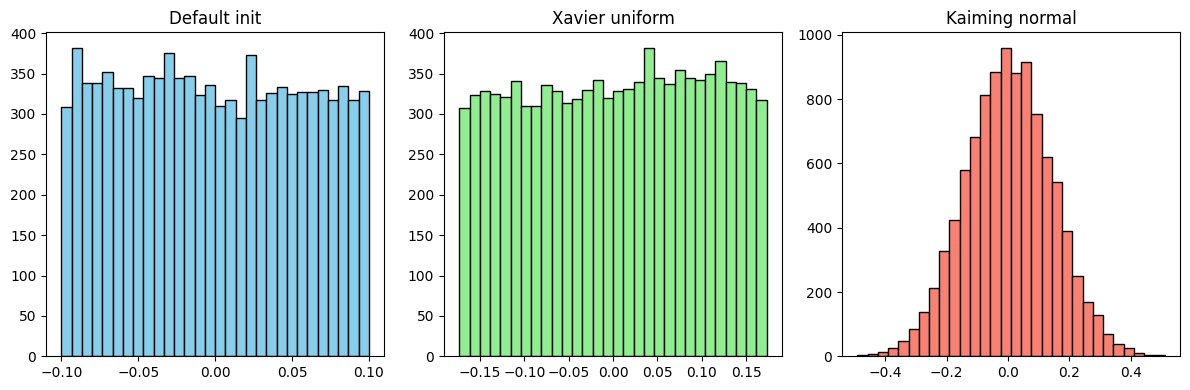

In [ ]:
import torch.nn as nn

layer = nn.Linear(100, 100, bias=False)

# 1. Default (uniform из [-1/sqrt(in), 1/sqrt(in)])
default_weights = layer.weight.detach().clone().view(-1).cpu().numpy()

# 2. Xavier uniform
nn.init.xavier_uniform_(layer.weight)
xavier_weights = layer.weight.detach().clone().view(-1).cpu().numpy()

# 3. Kaiming normal (ReLU)
nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
kaiming_weights = layer.weight.detach().clone().view(-1).cpu().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(default_weights, bins=30, color="skyblue", edgecolor="black")
plt.title("Default init")

plt.subplot(1, 3, 2)
plt.hist(xavier_weights, bins=30, color="lightgreen", edgecolor="black")
plt.title("Xavier uniform")

plt.subplot(1, 3, 3)
plt.hist(kaiming_weights, bins=30, color="salmon", edgecolor="black")
plt.title("Kaiming normal")

plt.tight_layout()
plt.show()

### `Dropout`:

Dropout is a method of regularizing neural networks that helps reduce the risk of overfitting.

During training, Dropout randomly sets the output activations of some neurons to zero with probability $p$, reducing their contribution to further calculations.

**Dropout formula:**

$$
y = \frac{1}{1-p} \cdot (x \odot m), \quad m \sim \text{Bernoulli}(1-p)
$$

where:

- $x$ is the activation vector,
- $m$ is a binary mask (0 or 1),
- $\odot$ is element-wise multiplication.

Scaling by $\frac{1}{1-p}$ is necessary to preserve the mathematical expectation of activations:

$$
\mathbb{E}[y] = \mathbb{E}[x].
$$

Otherwise, the average signal level at each layer would vary depending on the probability of zeroing, which would interfere with training.

Dropout prevents the network from relying too much on individual connections and helps form more stable features.

During inference, zeroing is not performed—the network uses all activations that have already been scaled during training.

Intuition:

– During training, some neurons “do not pass the signal on.”

– This forces neighboring neurons not to rely solely on specific connections, but to look for more stable combinations of features.

– At the inference (test) stage, no neuron is reset to zero—the entire network is used, but with scaled weights/activations.

In [ ]:
layer = nn.Dropout(p=0.5)
print(layer(torch.tensor([[1, 1, 1, 1]], dtype=torch.float)))

tensor([[2., 0., 2., 0.]])


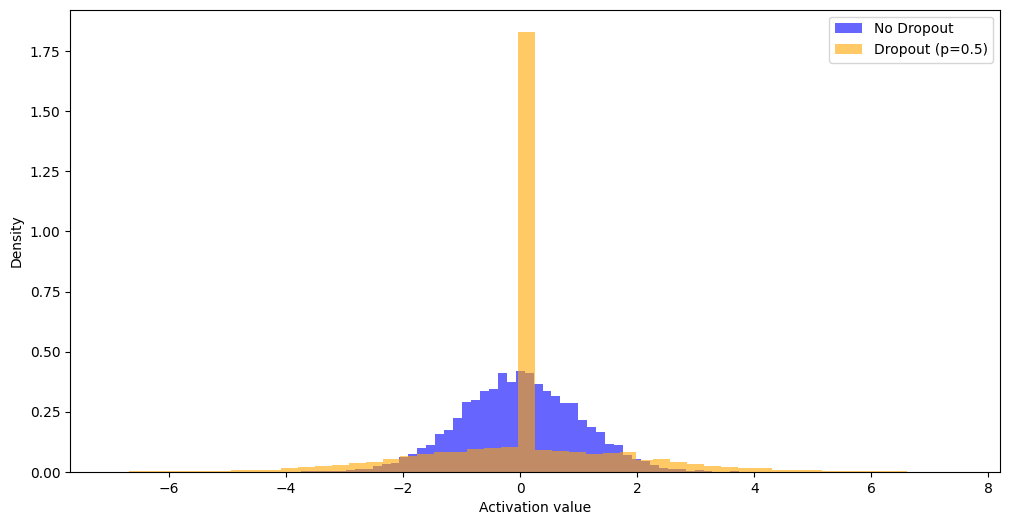

In [ ]:
x = torch.randn(10000)

dropout = nn.Dropout(p=0.5)
x_dropped = dropout(x)

x_np = x.detach().numpy()
x_dropped_np = x_dropped.detach().numpy()

plt.figure(figsize=(12, 6))
plt.hist(x_np, bins=50, alpha=0.6, label="No Dropout", density=True, color="blue")
plt.hist(
    x_dropped_np,
    bins=50,
    alpha=0.6,
    label="Dropout (p=0.5)",
    density=True,
    color="orange",
)

plt.xlabel("Activation value")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import clear_output, display
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm

In [ ]:
torch.manual_seed(1337)
random.seed(1337)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda:0


## Cross-Entropy

### Binary classification

Let's follow Bishop's definition (https://scholar.google.com/citations?user=gsr-K3ADUvAC&hl=en)

Consider binary classification with target variable $t\in\{0,1\}$, where $t=1$ is class $C_1$ and $t=0$ is class $C_2$.

Let the neural network have one output with a logistic sigmoid, so that $0\le y(\mathbf{x},\mathbf{w})\le 1$.

We interpret $y(\mathbf{x},\mathbf{w})$ as $p(C_1\mid \mathbf{x})$, then $p(C_2\mid \mathbf{x})=1-y(\mathbf{x},\mathbf{w})$.

**Conditional Bernoulli distribution:**
$$
p(t\mid \mathbf{x},\mathbf{w})=y(\mathbf{x},\mathbf{w})^{\,t}\,[1-y(\mathbf{x},\mathbf{w})]^{\,1-t}.
$$

For a training set of independent observations, the error function is the negative log likelihood (cross-entropy):
$$
E(\mathbf{w})=-\sum_{n=1}^{N}\Big[t_n\ln y_n+(1-t_n)\ln(1-y_n)\Big],
$$
where $y_n \equiv y(\mathbf{x}_n,\mathbf{w})$.

> In practice, using cross-entropy instead of sum of squares often speeds up training and improves generalization (Simard, Steinkraus, Platt, 2003).

Let's summarize everything we've covered so far.

Cross-entropy is a **fair quality scale** for model probabilities.

**Logic:**
- The model doesn't just say “0/1”; it gives the **probability** of the correct class.
- If you assign a high probability to the correct class, that's good; if you are **confidently wrong**, then we penalize heavily
- **Penalty for one example:**
  $$
  -\big[t\log y + (1-t)\log(1-y)\big].
  $$
  Here, $y$ is the predicted probability of “class = 1,” and $t\in\{0,1\}$ is the true label.

**Training:**
- We sum over the dataset and **minimize**:
  $$
  E(\mathbf{w}) \;=\; -\sum_{n=1}^{N}\Big[t_n\log y_n + (1-t_n)\log(1-y_n)\Big],
  $$
  where $y_n = y(\mathbf{x}_n,\mathbf{w})$.

In [ ]:
def binary_cross_entropy(y_pred, y_true, epsilon=1e-7):
    """

    E = -1/N * Σ[t*ln(y) + (1-t)*ln(1-y)], t – это y_true
    """

    # log(0)
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

    loss = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))

    return loss.mean()

In [ ]:
z = torch.tensor([[-1.0, 0.2, 2.5], [0.0, -4.0, 1.0]])
p = torch.sigmoid(z)
y = torch.tensor([[0.0, 1.0, 1.0], [0.0, 0.0, 1.0]])

loss_ours = binary_cross_entropy(p, y)
loss_ref = F.binary_cross_entropy(p, y, reduction="mean")

In [ ]:
print("loss_ours", loss_ours)
print("loss_ref", loss_ref)

loss_ours tensor(0.3358)
loss_ref tensor(0.3358)


### Independent binary classifications (K outputs)

If we need to perform $K$ **separate** binary classifications, we use a neural network with $K$ outputs, each with a sigmoid function.  
Let the label of class $k$ be: $t_k\in\{0,1\}$, $k=1,\dots,K$.  
Assuming independence of labels, the conditional distribution is:
$$
p(\mathbf{t}\mid \mathbf{x},\mathbf{w})
=\prod_{k=1}^{K} y_k(\mathbf{x},\mathbf{w})^{\,t_k}\,[1-y_k(\mathbf{x},\mathbf{w})]^{\,1-t_k}.
$$

**Negative log-likelihood (cross-entropy):**
$$
E(\mathbf{w})
=-\sum_{n=1}^{N}\sum_{k=1}^{K}
\Big[t_{nk}\ln y_{nk}+(1-t_{nk})\ln(1-y_{nk})\Big],
$$
where $y_{nk}\equiv y_k(\mathbf{x}_n,\mathbf{w})$.

> The derivatives of this error function with respect to the preliminary activations of a specific output have a standard form (as in the case of regression): the gradient is proportional to $y - t$, which provides a simple and stable training signal.


## Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift

This is the title of the original article (https://arxiv.org/abs/1502.03167) that started it all.

**Batch Normalization (BatchNorm)** is one of the key methods for stabilizing and accelerating neural network training. **BatchNorm** is needed to combat the problem of *internal covariate shift*, when the distribution of inputs to each layer of the network changes significantly as weights are updated, slowing down training.  

Simply put, when we train a neural network, some “intermediate data” appears on each layer – activations. The problem is that this data is constantly “floating”: after each iteration of training, the distribution of values at the layer input changes because the weights of the previous layers have been updated. This is called internal covariate shift.

### Formulas

Let us have input data $x_1, x_2, \dots, x_m$ in a batch of size $m$.  
The normalization process looks like this:  

1. Calculate the batch mean:

    $$
    \mu_B = \frac{1}{m} \sum_{i=1}^m x_i
    $$

2. Calculate the variance (spread of values):

    $$
    \sigma_B^2 = \frac{1}{m} \sum_{i=1}^m (x_i - \mu_B)^2
    $$

3. Normalize each value (bring it to zero mean and unit variance):

    $$
    \hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
    $$

where $\epsilon$ is a very small constant needed for numerical stability (to avoid division by zero).

4. Add the trainable parameters (scale $\gamma$ and bias $\beta$):

$$
    y_i = \gamma \hat{x}_i + \beta
    $$


> P.S. This is a very popular question at job interviews.

### How BatchNorm works in `train()` and `eval()` in PyTorch

**In `model.train()` mode**
- We normalize **based on the statistics of the current mini-batch**:
  
  $
  y = \gamma \cdot \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}} + \beta
  $

  where $\mu_B$, $\sigma_B^2$ are the mean and variance of the batch
  (for Conv — calculated along the \(N,H,W\) axes for each channel, but more on that later).

- **Running statistics** — exponential smoothing:
  
  $
  \text{running\_mean} \leftarrow (1-m)\,\text{running\_mean} + m\,\mu_B
  $
  
  $
  \text{running\_var} \leftarrow (1-m)\,\text{running\_var} + m\,\sigma_B^2
  $
  
  where `momentum = m` (default 0.1).  
  If `momentum=None`, the cumulative mean (based on the `num_batches_tracked` counter) is used.

---
**In `model.eval()` mode**
- Statistics **are not updated**.
- Normalization is based on **accumulated** estimates:
  
  $
  y = \gamma \cdot \frac{x - \text{running\_mean}}{\sqrt{\text{running\_var} + \varepsilon}} + \beta
  $
  
  This makes inference stable and independent of the composition of the current batch.

---

#### What does “accumulating statistics” mean?
Storing smoothed estimates of means and variances of features (by channel) in the `running_mean` and `running_var` buffers.  
They approximate “population” values and are used in `eval()` instead of noisy batch estimates.

---

#### Useful nuances
- `track_running_stats=False` → BN **always** uses batch stats and does not store running buffers (even in `eval()`), the output depends on the size/composition of the batch.
- `affine=False` disables trainable $\gamma$, $\beta$.
- Very small batches → inaccurate stats: consider **LayerNorm/GroupNorm/InstanceNorm**.
- `torch.no_grad()` **does not switch** BN in `eval()` — an explicit call to `model.eval()` is required.

### BatchNorm by hand on PyTorch

In [ ]:
x = torch.tensor(
    [
        [0.4963, 0.7682, 0.0885],
        [0.1320, 0.3074, -0.6343],
        [0.4901, -0.1123, -0.1152],
        [-0.2814, 0.1494, -0.2310],
    ]
)

In [ ]:
mu_B = x.mean(dim=0, keepdim=True)
print("\nMean (mu_B):\n", mu_B)


Mean (mu_B):
 tensor([[ 0.2093,  0.2782, -0.2230]])


In [ ]:
var_B = x.var(dim=0, unbiased=False, keepdim=True)
print("\nVar (sigma_B^2):\n", var_B)


Var (sigma_B^2):
 tensor([[0.1020, 0.1025, 0.0695]])


In [ ]:
eps = 1e-5
x_hat = (x - mu_B) / torch.sqrt(var_B + eps)
print("\nNormalized values (x_hat):\n", x_hat)


Normalized values (x_hat):
 tensor([[ 0.8988,  1.5304,  1.1817],
        [-0.2419,  0.0913, -1.5604],
        [ 0.8794, -1.2195,  0.4090],
        [-1.5362, -0.4022, -0.0303]])


In [ ]:
gamma = torch.ones(1, 3)  # scale
beta = torch.zeros(1, 3)  # mean

y = gamma * x_hat + beta
print("\nBatchNorm (y):\n", y)


Выход после BatchNorm (y):
 tensor([[ 0.8988,  1.5304,  1.1817],
        [-0.2419,  0.0913, -1.5604],
        [ 0.8794, -1.2195,  0.4090],
        [-1.5362, -0.4022, -0.0303]])


#### Let's compare

In [ ]:
bn = torch.nn.BatchNorm1d(num_features=3, affine=True, track_running_stats=False)

with torch.no_grad():
    bn.weight.copy_(gamma.squeeze())
    bn.bias.copy_(beta.squeeze())

y_bn = bn(x)
print("\nPyTorch nn.BatchNorm1d:\n", y_bn)


PyTorch nn.BatchNorm1d:
 tensor([[ 0.8988,  1.5304,  1.1817],
        [-0.2419,  0.0913, -1.5604],
        [ 0.8794, -1.2195,  0.4090],
        [-1.5362, -0.4022, -0.0303]], grad_fn=<NativeBatchNormBackward0>)


In [ ]:
torch.allclose(y_bn, y, atol=1e-6)

True

### Gradient fading: what is it and how does it work?

A situation where, with backprop, gradients decrease exponentially in the early layers and training “stalls,” loss plateau.

Strangely enough, not only dropout, initialization, and other activations help, but also **normalization**.

Let's look at an example of gradient fading using a synthetic example:

In [ ]:
N = 2048  # obj
D_in = 64  # features
D_hidden = 128
D_out = 1

In [ ]:
X = torch.randn(N, D_in)
w_true = torch.randn(D_in, D_out)
y = X @ w_true + 0.1 * torch.randn(N, D_out)

In [ ]:
batch_size = 128
dataset = torch.utils.data.TensorDataset(X, y)
train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=False
)

In [ ]:
class ClassicMLP(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, depth=20, use_bn=False):
        super().__init__()
        layers = []
        layers.append(nn.Linear(d_in, d_hidden))
        if use_bn:
            layers.append(nn.BatchNorm1d(d_hidden))
        layers.append(nn.ReLU(inplace=False))

        for _ in range(depth - 2):
            layers.append(nn.Linear(d_hidden, d_hidden))
            if use_bn:
                layers.append(nn.BatchNorm1d(d_hidden))
            layers.append(nn.ReLU(inplace=False))

        layers.append(nn.Linear(d_hidden, d_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_model(
    model, optimizer, train_loader, loss_fn=nn.MSELoss(), epochs=200, label="no_bn"
):

    grad_norms, losses = [], []

    pbar = tqdm(range(epochs), desc=f"[{label}] training", unit="epoch")
    for epoch in pbar:
        epoch_losses = []
        epoch_grad_norms = []

        for x_train, y_train in train_loader:
            x_train, y_train = x_train.to(device), y_train.to(device)

            optimizer.zero_grad()

            pred = model(x_train)
            loss = loss_fn(pred, y_train)

            loss.backward()

            # L2 grad norm
            total_sq = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_sq += p.grad.detach().pow(2).sum().item()
            grad_norm = math.sqrt(total_sq)

            # Explosion?
            if (not math.isfinite(grad_norm)) or (not math.isfinite(loss.item())):
                print(
                    f"[{label}] epoch {epoch}, batch: grad_norm={grad_norm}, loss={loss.item()} → остановка (взрыв)."
                )
                if len(losses) > 0 or len(grad_norms) > 0:
                    clear_output(wait=True)
                    fig = plt.figure(figsize=(10, 4))
                    plt.subplot(1, 2, 1)
                    plt.plot(grad_norms, "-o", markersize=3)
                    plt.title("grad_norm")
                    plt.xlabel("epoch")
                    plt.ylabel("||grad||₂")

                    plt.subplot(1, 2, 2)
                    plt.plot(losses, "-o", markersize=3)
                    plt.title("loss")
                    plt.xlabel("epoch")
                    plt.ylabel("loss")
                    plt.tight_layout()
                    display(fig)
                return grad_norms, losses

            epoch_losses.append(loss.item())
            epoch_grad_norms.append(grad_norm)

            # Step
            optimizer.step()

        # Save metrics
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        avg_grad_norm = sum(epoch_grad_norms) / len(epoch_grad_norms)

        losses.append(avg_loss)
        grad_norms.append(avg_grad_norm)

        pbar.set_postfix(loss=f"{avg_loss:.4f}", grad_norm=f"{avg_grad_norm:.2e}")

        if (epoch + 1) % 10 == 0:
            clear_output(wait=True)
            print(
                f"[{label}] epoch {epoch+1:3d}: loss={avg_loss:.4f}, grad_norm={avg_grad_norm:.2e}"
            )
            fig = plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            plt.plot(grad_norms, "-o", markersize=3)
            plt.title("grad_norm")
            plt.xlabel("epoch")
            plt.ylabel("||grad||₂")

            plt.subplot(1, 2, 2)
            plt.plot(losses, "-o", markersize=3)
            plt.title("loss")
            plt.xlabel("epoch")
            plt.ylabel("loss")
            plt.tight_layout()
            # display(fig)

    return grad_norms, losses

[no_batch_norm] epoch 100: loss=65.4326, grad_norm=1.04e+00


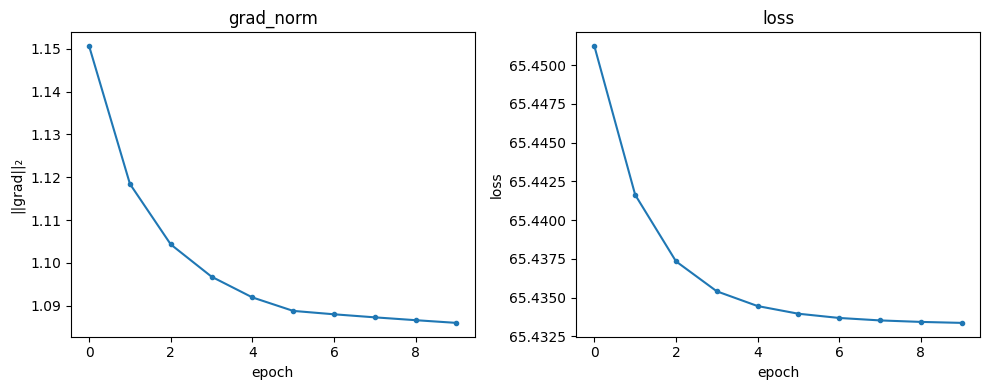

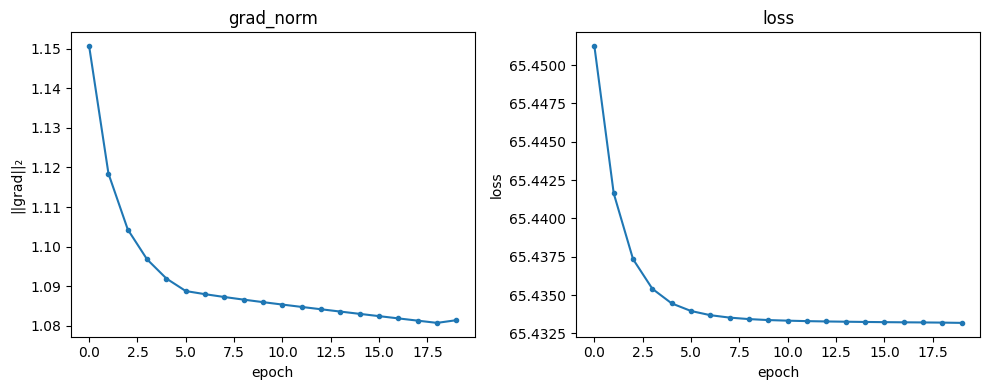

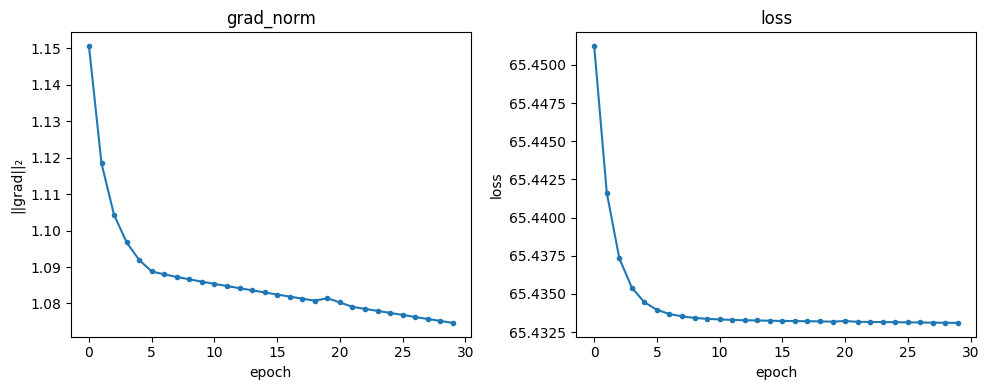

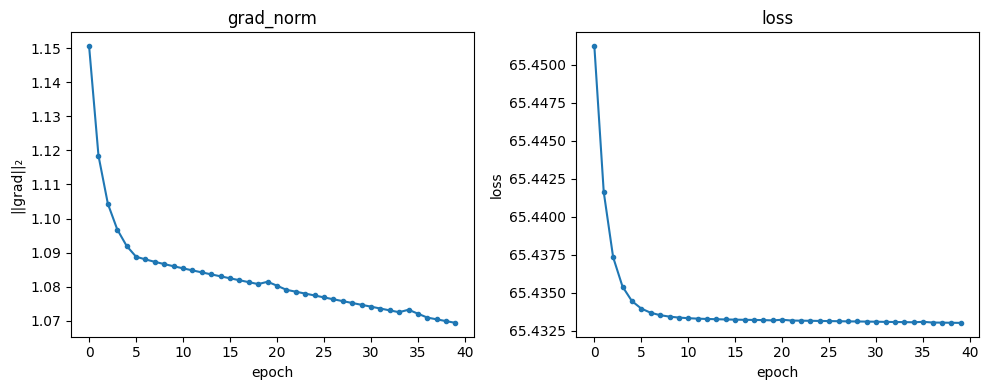

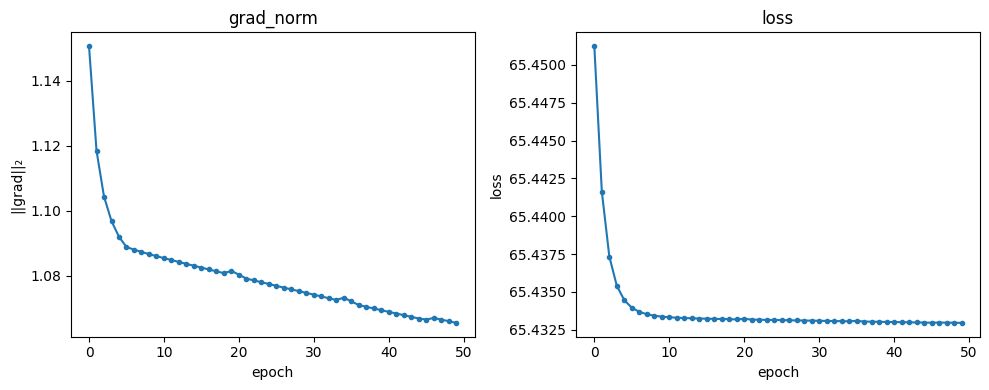

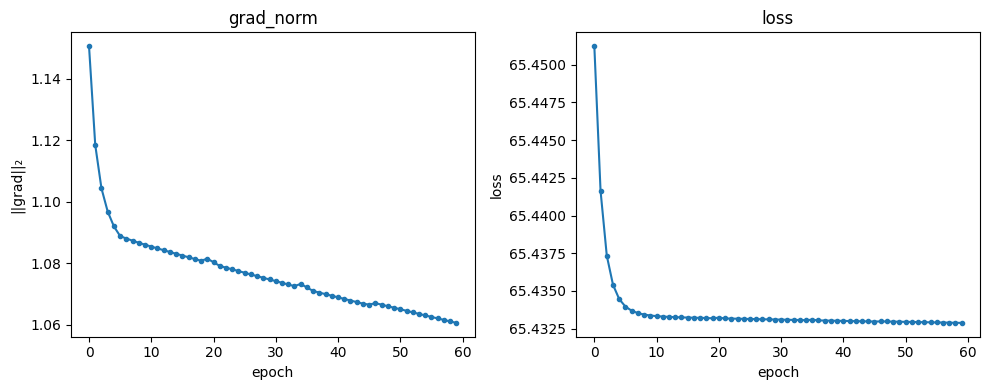

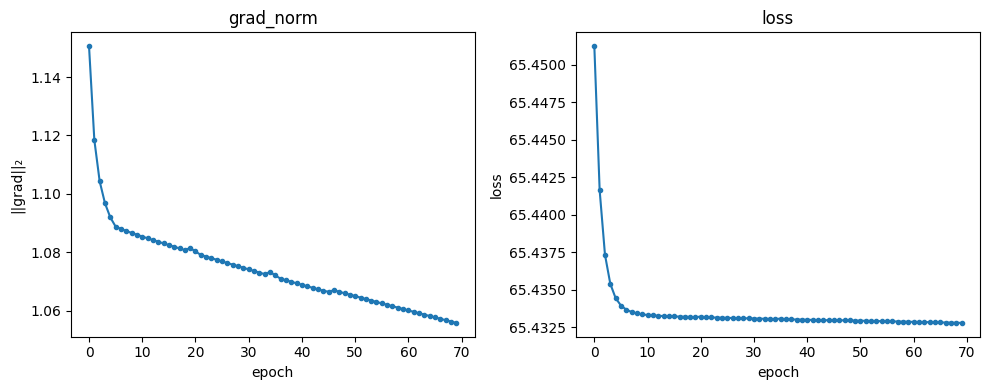

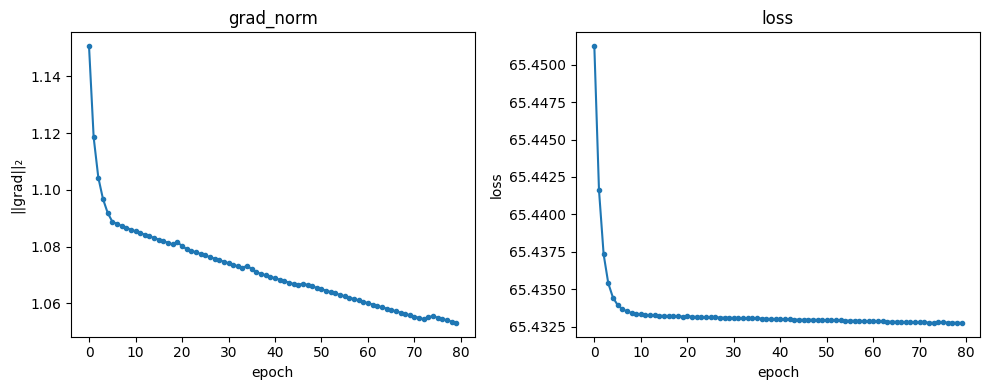

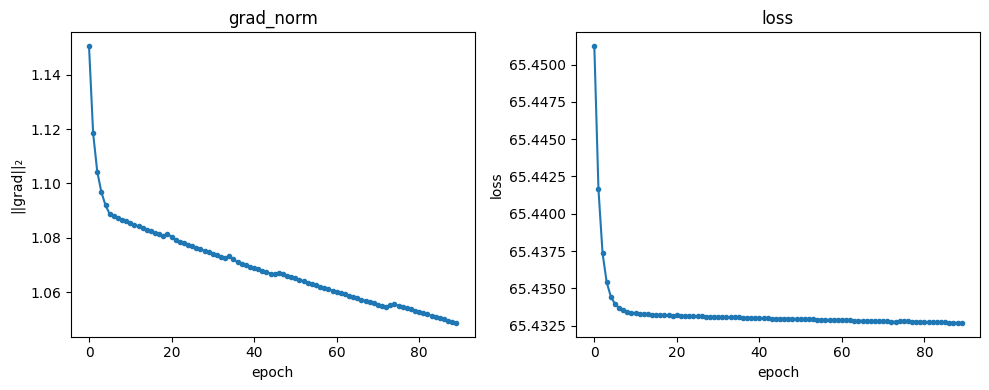

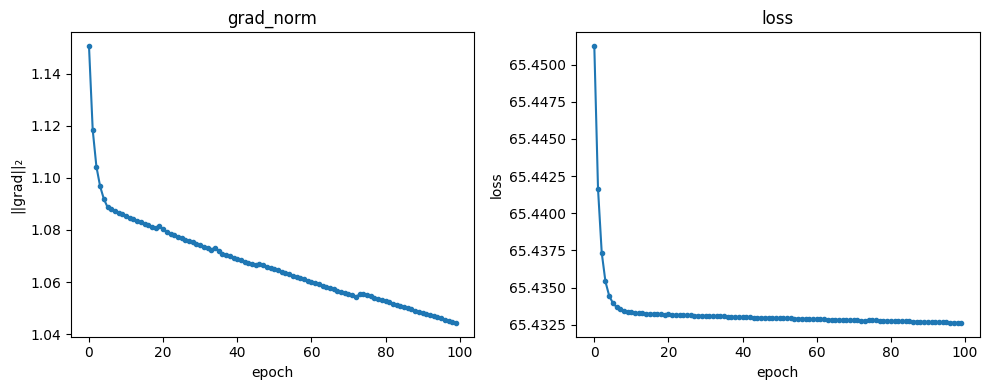

In [ ]:
depth = 20
lr = 1e-2  # we are trying to shoot ourselves in the foot
epochs = 100

model_no_batch_norm = ClassicMLP(D_in, D_hidden, D_out, depth=depth, use_bn=False)
model_no_batch_norm = model_no_batch_norm.to(device)
optimizer_no_batch_norm = torch.optim.SGD(model_no_batch_norm.parameters(), lr=lr)


gn_no_bn, loss_no_bn = train_model(
    model_no_batch_norm,
    optimizer_no_batch_norm,
    train_loader,
    epochs=epochs,
    label="no_batch_norm",
)

[with_batch_norm] epoch 100: loss=0.0074, grad_norm=1.54e+00


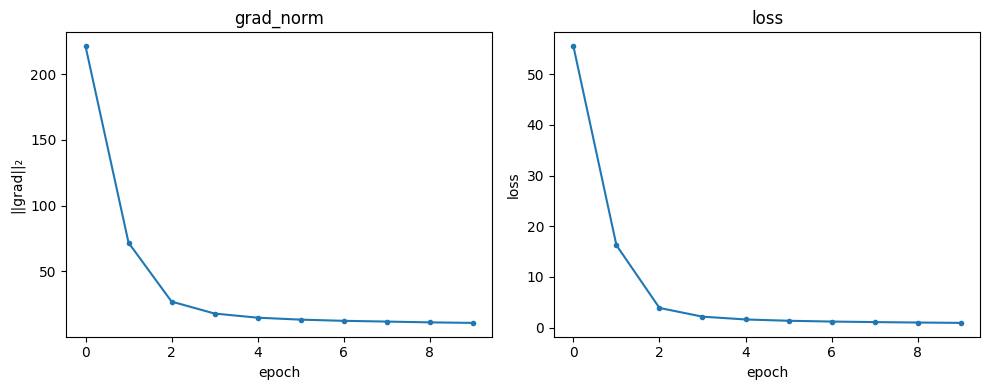

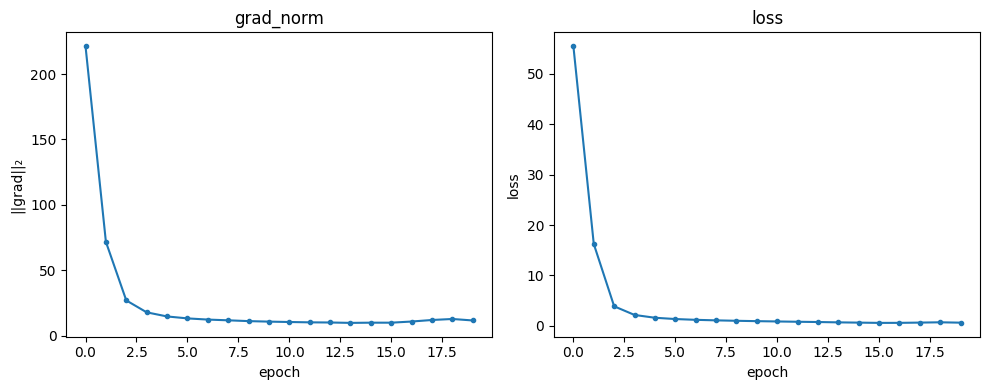

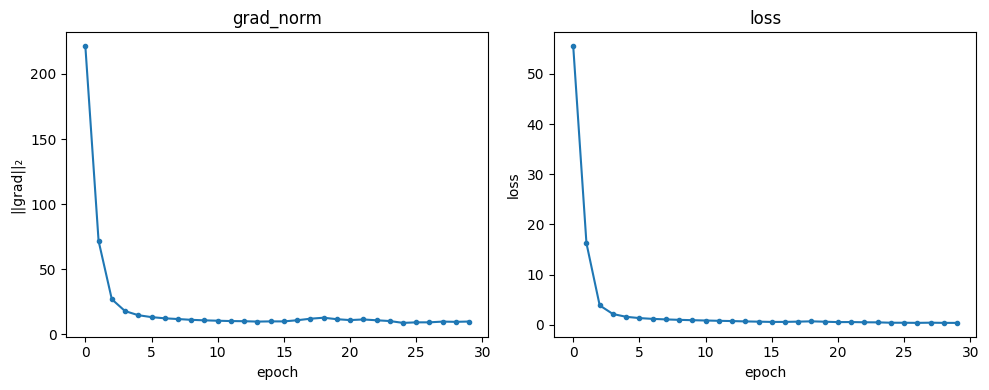

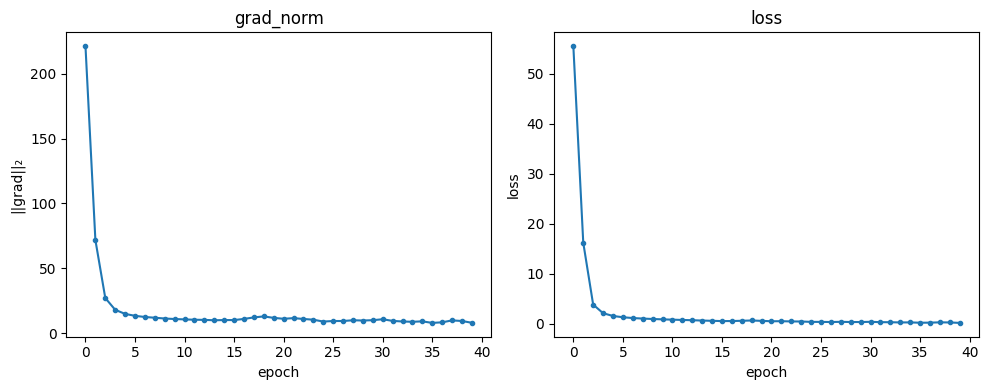

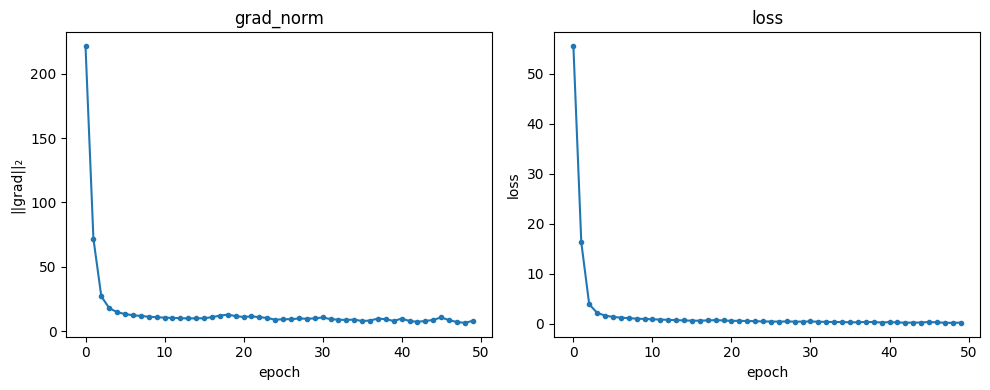

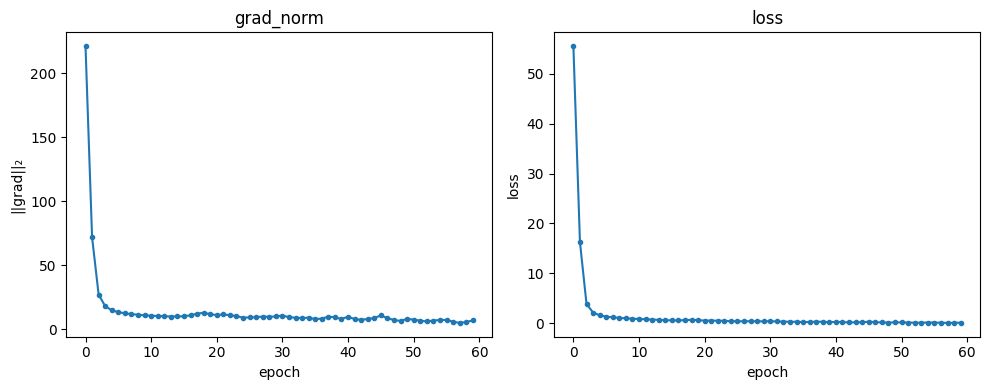

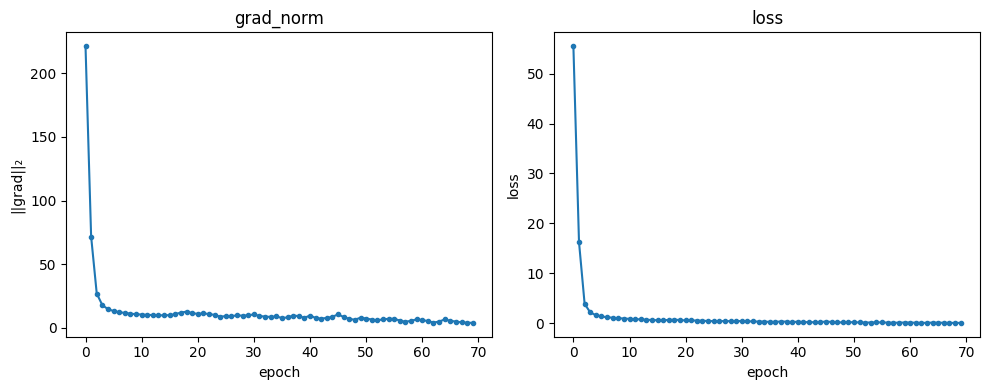

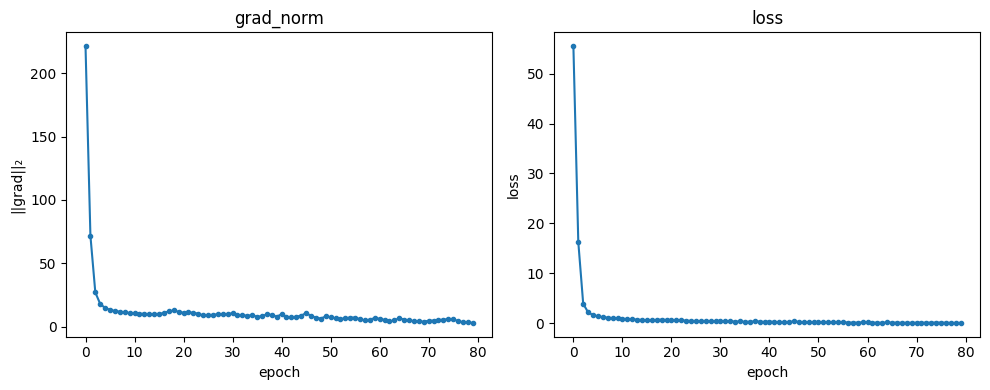

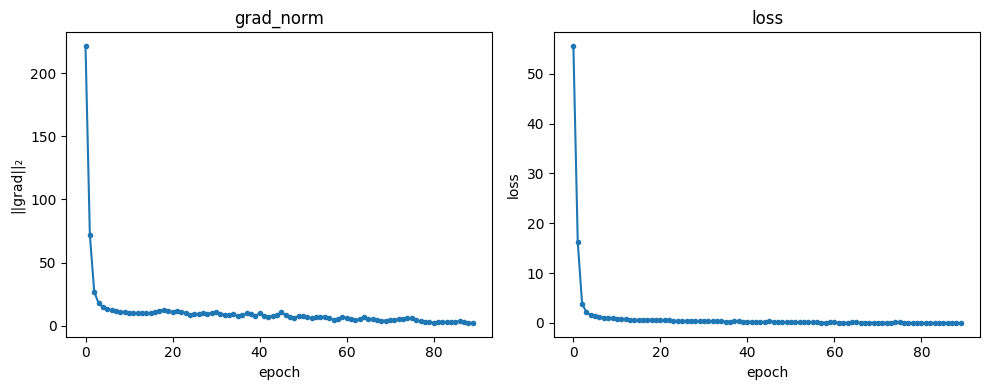

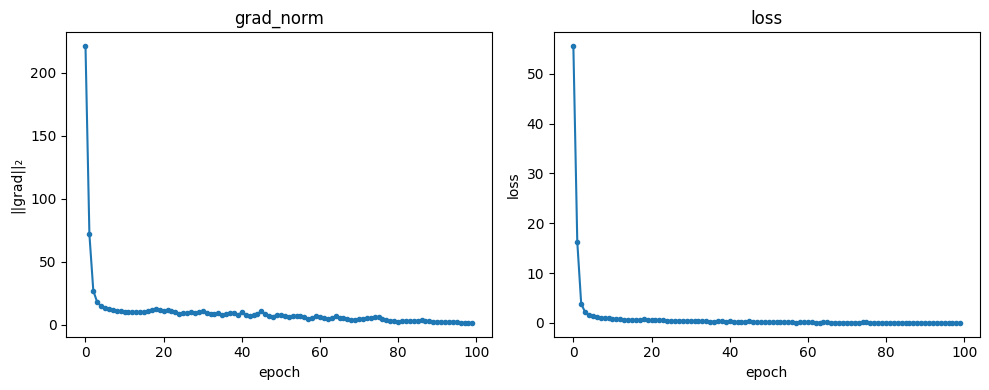

In [ ]:
depth = 20
lr = 1e-2
epochs = 100

model_with_batch_norm = ClassicMLP(D_in, D_hidden, D_out, depth=depth, use_bn=True)
model_with_batch_norm = model_with_batch_norm.to(device)
optimizer_with_batch_norm = torch.optim.SGD(model_with_batch_norm.parameters(), lr=lr)


gn_with_bn, loss_with_bn = train_model(
    model_with_batch_norm,
    optimizer_with_batch_norm,
    train_loader,
    epochs=epochs,
    label="with_batch_norm",
)

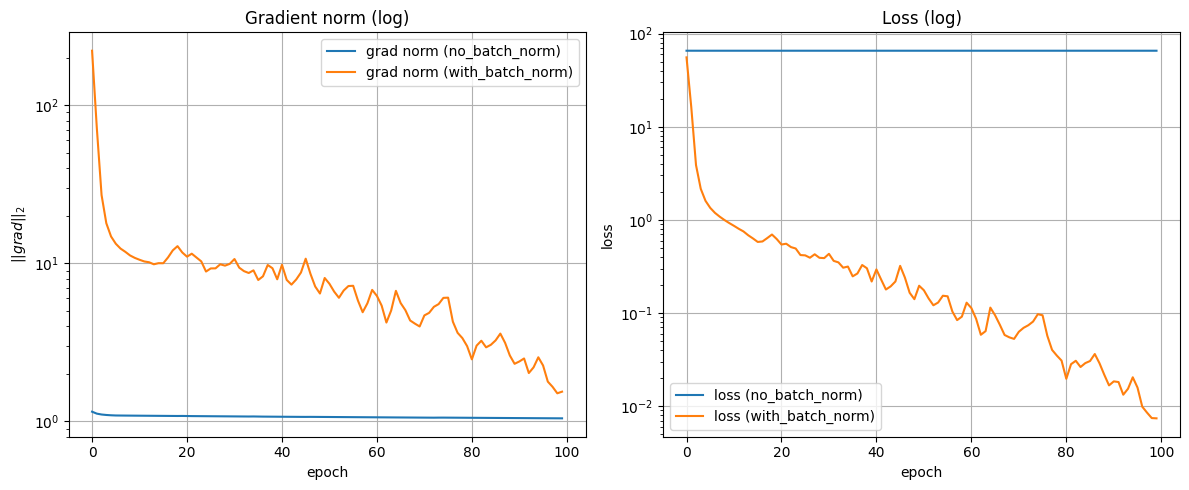

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gn_no_bn, label="grad norm (no_batch_norm)")
plt.plot(gn_with_bn, label="grad norm (with_batch_norm)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("$||grad||_2$")
plt.title("Gradient norm (log)")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(loss_no_bn, label="loss (no_batch_norm)")
plt.plot(loss_with_bn, label="loss (with_batch_norm)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss (log)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Here you can see a classic example of vanishing gradients.

#### Left graph

The graph without normalization is horizontal and very low throughout—the gradients are tiny → the optimizer's steps are microscopic → the network is essentially not learning.

The graph with normalization starts with large values (tens to hundreds), then quickly declines and fluctuates within a reasonable range, gradually decreasing. This is a healthy picture: the gradients are large enough to move the weights, and as they approach the minimum, they become smaller.

#### Right graph

The graph without the norm—a plateau at a high level—confirms that without BN, the model is stuck and the gradients have decayed.

The graph with the norm drops by several orders of magnitude (to 1e-2) with small “waves”—training is progressing, and loss is decreasing.

### Gradient explosion

Gradient explosion occurs when derivatives grow uncontrollably, optimizer steps are huge, loss jumps, and NaN/Inf appear.

Causes: too high learning rate, poor initialization, very deep networks/RNN, lack of normalization.

Countermeasures: reduce LR, gradient clipping, **normalization!**, correct initialization, residual connections, weight decay.

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

batch_size = 4096
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


In [ ]:
class DeepMLP(nn.Module):
    def __init__(self, in_dim=28 * 28, hidden=512, depth=12, use_bn=False):
        super().__init__()
        layers = []
        layers += [nn.Linear(in_dim, hidden)]
        if use_bn:
            layers += [nn.BatchNorm1d(hidden)]
        layers += [nn.Tanh()]  # tanh for breaking

        for _ in range(depth - 2):
            layers += [nn.Linear(hidden, hidden)]
            if use_bn:
                layers += [nn.BatchNorm1d(hidden)]
            layers += [nn.Tanh()]

        layers += [nn.Linear(hidden, 10)]  # logits for CrossEntropy
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


def grad_norm(model):
    total_sq = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total_sq += p.grad.detach().pow(2).sum().item()
    return math.sqrt(total_sq) if total_sq > 0 else 0.0


def evaluate(model, test_loader, loss_fn=nn.CrossEntropyLoss()):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_sum += loss_fn(logits, y).item() * x.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return loss_sum / total, correct / total

In [ ]:
def train_model(
    model,
    optimizer,
    train_loader,
    test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=100,
    label="no_bn",
    plot_every_epochs=10,
):
    model.to(device)
    gns, losses = [], []
    global_step = 0
    early_stop = False

    pbar = tqdm(range(epochs), desc=f"[{label}] training", unit="epoch")
    for epoch in pbar:
        model.train()
        for batch_idx, (x_train, y_train) in enumerate(train_loader):
            x_train, y_train = x_train.to(device), y_train.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x_train)
            loss = loss_fn(logits, y_train)
            loss.backward()

            total_sq = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_sq += p.grad.detach().pow(2).sum().item()
            gn = math.sqrt(total_sq) if total_sq > 0 else 0.0

            gns.append(gn)
            losses.append(loss.item())

            # stop on NaN/Inf
            if not (math.isfinite(gn) and math.isfinite(loss.item())):
                print(
                    f"[{label}] epoch {epoch+1}, batch {batch_idx+1}: "
                    f"grad_norm={gn}, loss={loss.item()} → остановка (взрыв)."
                )
                early_stop = True
                break

            optimizer.step()
            global_step += 1

            pbar.set_postfix(loss=f"{loss.item():.4f}", grad_norm=f"{gn:.2e}")

        if ((epoch + 1) % plot_every_epochs == 0) or early_stop:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].plot(gns, "-o", markersize=2)
            axes[0].set_title("grad_norm")
            axes[0].set_xlabel("step")
            axes[0].set_ylabel("||grad||₂")
            axes[1].plot(losses, "-o", markersize=2)
            axes[1].set_title("loss")
            axes[1].set_xlabel("step")
            axes[1].set_ylabel("loss")
            plt.tight_layout()
            display(fig)
            plt.close(fig)

        if early_stop:
            print(
                f"[{label}] early stop at epoch {epoch+1}, global_step {global_step}."
            )
            break

    test_loss, test_acc = evaluate(model, test_loader)
    print(f"[{label}] TEST  loss={test_loss:.4f}, acc={test_acc:.4f}")
    return gns, losses

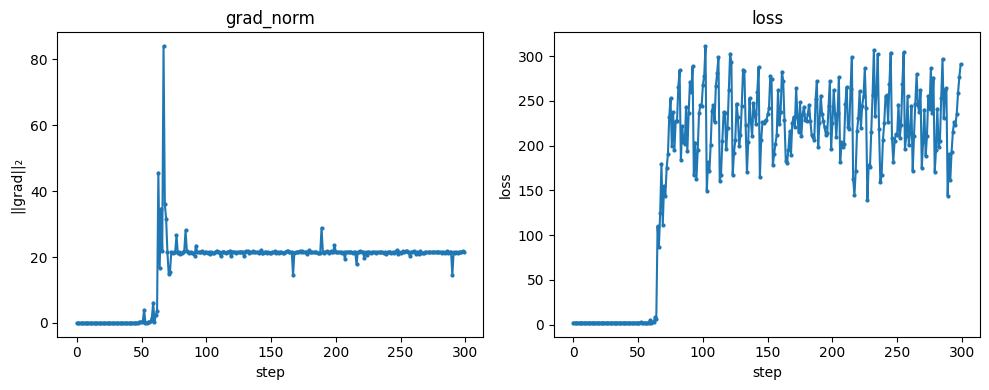

[NO_BN] TEST  loss=189.1776, acc=0.0974


In [ ]:
depth = 12
lr = 1.0  # we REALLY want to shoot our feet here
epochs = 20

model_no_batch_norm = DeepMLP(depth=depth, use_bn=False)
model_no_batch_norm = model_no_batch_norm.to(device)
optimizer_no_batch_norm = torch.optim.SGD(model_no_batch_norm.parameters(), lr=lr)

gn_no_bn, loss_no_bn = train_model(
    model_no_batch_norm,
    optimizer_no_batch_norm,
    train_loader,
    test_loader,
    epochs=epochs,
    label="NO_BN",
)

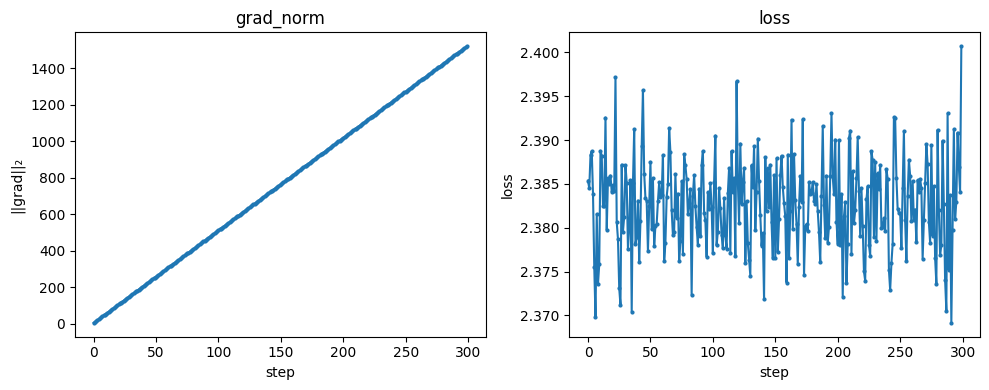

[WITH_BN] TEST  loss=2.3854, acc=0.0824


In [ ]:
model_with_batch_norm = DeepMLP(depth=depth, use_bn=True)
model_with_batch_norm = model_with_batch_norm.to(device)
optimizer_with_batch_norm = torch.optim.SGD(model_no_batch_norm.parameters(), lr=lr)

gn_with_bn, loss_with_bn = train_model(
    model_with_batch_norm,
    optimizer_with_batch_norm,
    train_loader,
    test_loader,
    epochs=epochs,
    label="WITH_BN",
)

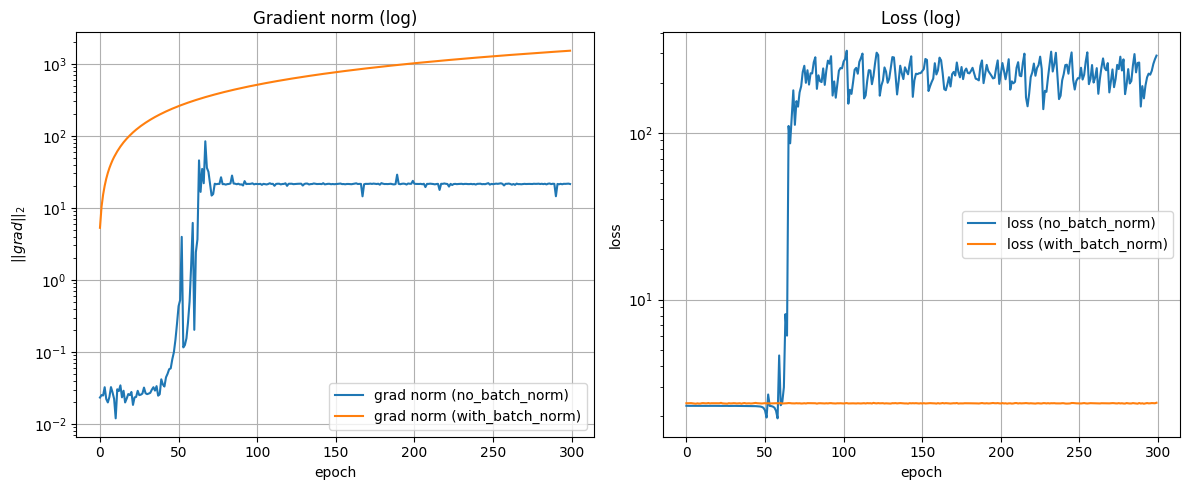

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gn_no_bn, label="grad norm (no_batch_norm)")
plt.plot(gn_with_bn, label="grad norm (with_batch_norm)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("$||grad||_2$")
plt.title("Gradient norm (log)")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(loss_no_bn, label="loss (no_batch_norm)")
plt.plot(loss_with_bn, label="loss (with_batch_norm)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss (log)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##### Left graph:

Without BatchNorm – At first, the gradients are tiny (almost stalling), then around epoch ~55, there is a sharp explosion by several orders of magnitude: the steps become gigantic, and divergence begins.

With BatchNorm – Grows smoothly and stays within reasonable limits – no sharp jumps or infinities. This is a sign of stable backpropagation.

##### Right graph:

Without normalization, a deep network with a large LR quickly goes into an area where activations/gradients inflate → the optimizer's steps become inadequate → the loss flies away

BatchNorm evens out the scale of activations in each layer, stabilizing backprop. Therefore, even with an inflated LR and great depth, training remains manageable.